In [3]:
%load_ext autoreload
%autoreload 2
from metocean_ml import geospatial, physics, spectra_tools, models
from skorch import dataset
import pandas as pd
import numpy as np
import skorch
import torch
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
plt.rcParams["axes.grid"] = True


## Data exploration

In [2]:
nora3 = xr.load_dataset("tests/data/NORA3_SULA.nc")
norac = xr.load_dataset("tests/data/NORAC_SULA_SPEC.nc")

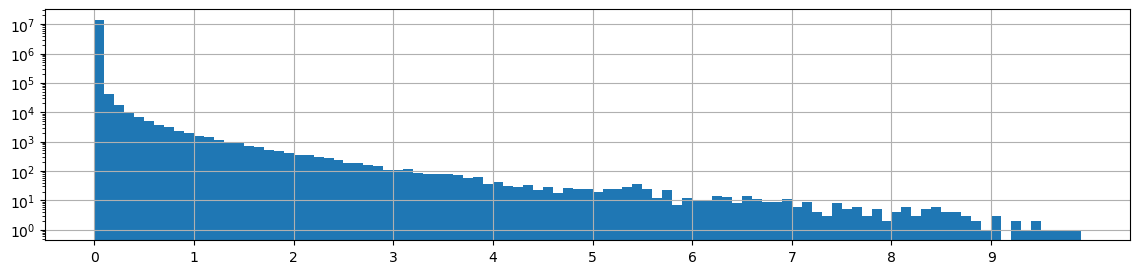

In [3]:
plt.rcParams["figure.figsize"] = (14,3)
plt.hist(norac["efth"].values.flatten(),bins=np.arange(0,10,0.1))
plt.yscale("log")
_=plt.xticks(np.arange(10))

In [4]:
from metocean_ml import spectra_tools
params = spectra_tools.integrated_parameters(norac["efth"],norac["frequency"],norac["direction"])
params["Ws"] = norac["wnd"].values
norac_params = pd.DataFrame(params,index=norac.time.values)
nora3_params = nora3.to_dataframe()

Calculating peak directions...: 100%|██████████| 8760/8760 [00:01<00:00, 5529.25it/s]


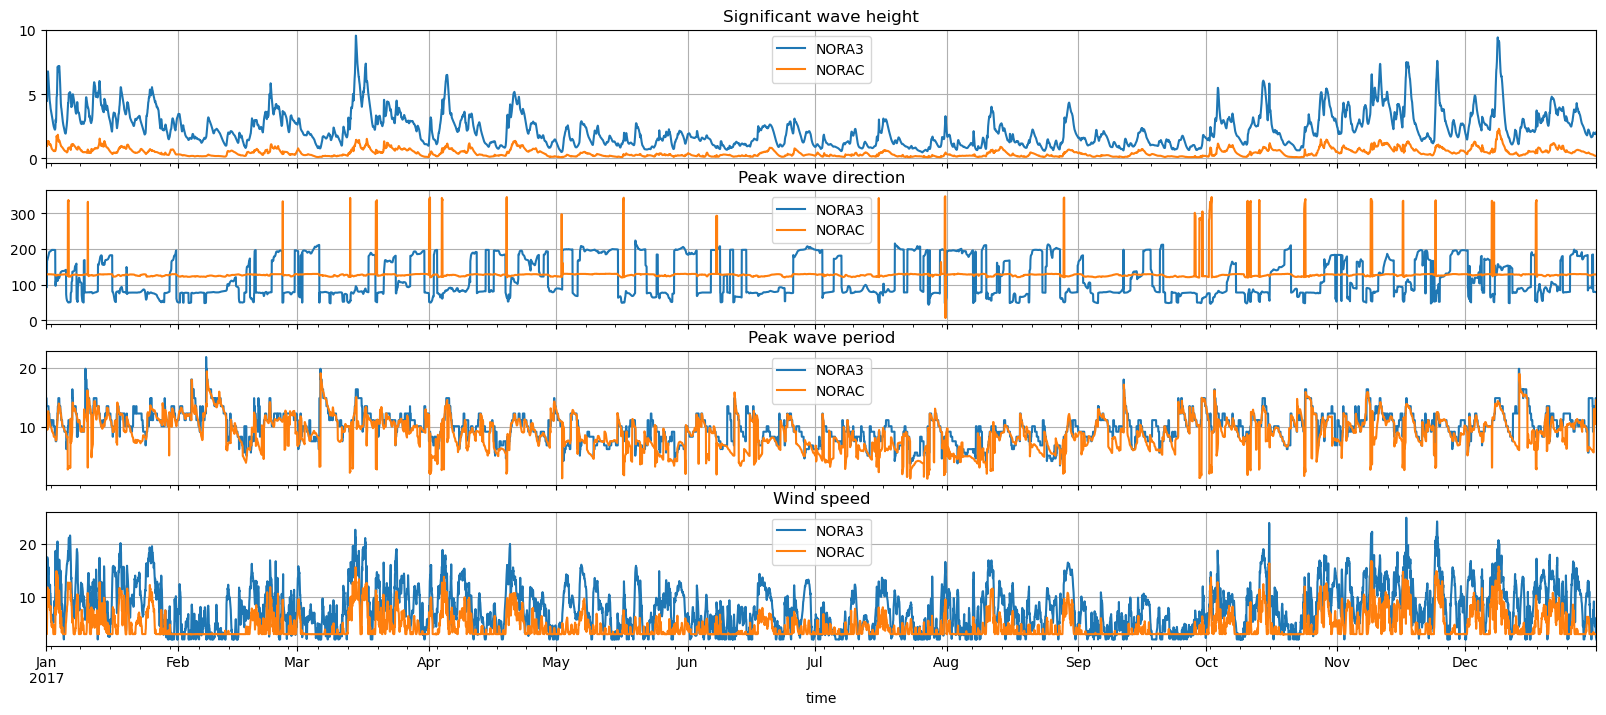

In [5]:
plt.rcParams["figure.figsize"] = (20,8)
ax = nora3_params[["hs","Pdir","tp","ff"]].plot(subplots=True,color="tab:blue")
norac_params[["Hs","peak_dir","peak_period","Ws"]].plot(subplots=True,ax=ax,color="tab:orange")
names = ["Significant wave height","Peak wave direction","Peak wave period","Wind speed"]
for i,n in enumerate(names):ax[i].set_title(n);ax[i].legend(["NORA3","NORAC"])

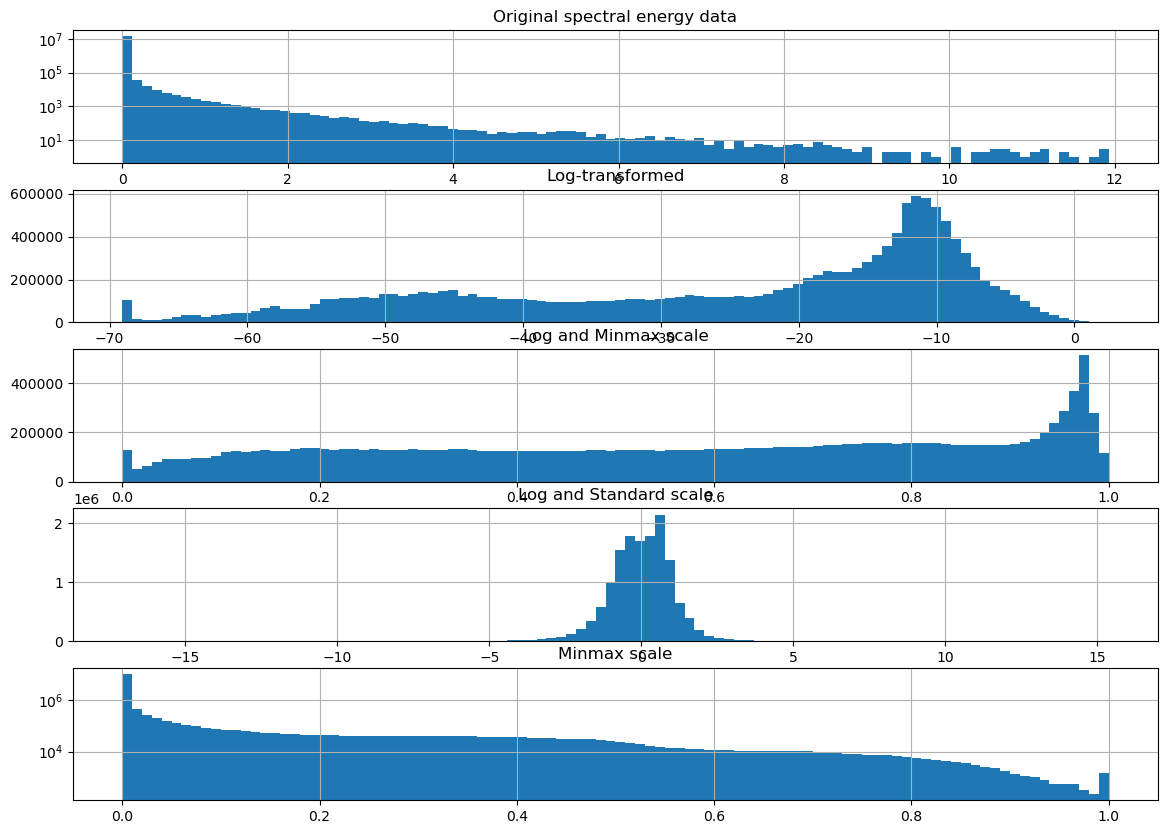

In [6]:
from sklearn.preprocessing import minmax_scale,StandardScaler
x = norac.efth.values.reshape(8760,-1)
plt.rcParams["figure.figsize"] = (14,10)
fig,ax = plt.subplots(5,1,sharex=False)
ax[0].hist(x.flatten(),bins=100)
ax[0].set_yscale("log")
logx = np.log(x+1e-30)
ax[1].hist(logx.flatten(),bins=100)
ax[2].hist(minmax_scale(logx).flatten(),bins=100)
ax[3].hist(StandardScaler().fit_transform(logx).flatten(),bins=100)
ax[4].hist(minmax_scale(x).flatten(),bins=100)
ax[4].set_yscale("log")
title = ["Original spectral energy data","Log-transformed","Log and Minmax scale","Log and Standard scale","Minmax scale"]
for i,t in enumerate(title):ax[i].set_title(t)
print()

## Pre-processing

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,QuantileTransformer,MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

def log_transform(x):
    if np.any(x<0):raise ValueError()
    return np.log(x+1e-30)
def log_inverse_transform(x):
    return np.exp(x)-1e-30

spec_shape = norac.efth.shape[-2:]
def spec_to_features(x):
    return x.reshape(x.shape[0],-1)
def features_to_spec(x):
    return x.reshape(-1,*spec_shape)

In [8]:
spectra_pipeline = Pipeline([
    ("spec_reshape",FunctionTransformer(spec_to_features,features_to_spec,check_inverse=False)),
    ("log-transform",FunctionTransformer(log_transform,log_inverse_transform,check_inverse=False)),
    ("PCA",PCA(200)),
    ("minmax-scaler",StandardScaler())
    ]
)
target_data_s = spectra_pipeline.fit_transform(norac.efth.values)

In [9]:
input_data = nora3.to_dataframe()[["ff","dd","hs","hs_sea","hs_swell","thq","thq_sea","thq_swell","tm1","tm2","tmp","tp","tp_sea","tp_swell"]]
local_wind = norac[["wnd","wnddir"]].to_dataframe()[["wnd","wnddir"]]
input_data = pd.concat([input_data,local_wind],axis=1)

In [10]:
input_data["norac_u"],input_data["norac_v"] = physics.dirmag_to_uv(input_data["wnddir"],input_data["wnd"])
input_data["nora3_u"],input_data["nora3_v"] = physics.dirmag_to_uv(input_data["dd"],input_data["ff"])
input_data = input_data.drop(["dd","ff","wnd","wnddir"],axis=1)

In [11]:
input_pipeline = StandardScaler()
input_data_s = input_pipeline.fit_transform(input_data)

In [12]:
split = int(0.5*len(input_data_s))
train_input = input_data_s[:split]
train_target = target_data_s[:split]
test_input = input_data_s[split:]
test_target = target_data_s[split:]

## Machine learning

In [77]:
from skorch import NeuralNetRegressor
from torch.nn import MSELoss,L1Loss
from torch.optim import Adam

#model = models.LNN(input_data_s.shape[1],target_data_s.shape[1])
model = models.FNN(input_data_s.shape[1],target_data_s.shape[1],layers=[50])
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
model = NeuralNetRegressor(
    model,
    criterion=L1Loss,
    optimizer=Adam,
    max_epochs=200,
    lr=0.1,
    train_split=None,
    )

11050


In [78]:
model.fit(train_input,train_target)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.1140  0.1092
      2        0.9249  0.0847
      3        0.8218  0.0850
      4        0.7988  0.0807
      5        0.7965  0.0789
      6        0.7970  0.0845
      7        0.8027  0.0754
      8        0.8251  0.0760
      9        0.8021  0.0892
     10        0.7969  0.0812
     11        0.7971  0.0818
     12        0.7976  0.0961
     13        0.7978  0.0988
     14        0.7967  0.0894
     15        0.7969  0.0765
     16        0.7971  0.0771
     17        0.7973  0.0755
     18        0.7974  0.0756
     19        0.7970  0.0741
     20        0.7969  0.0744
     21        0.7971  0.0805
     22        0.7966  0.0780
     23        0.8006  0.0823
     24        0.8026  0.0920
     25        0.7980  0.0956
     26        0.8000  0.1419
     27        0.7969  0.1012
     28        0.7970  0.1078
     29        0.7982  0.1404
     30        0.7976  0.1178
     31        0.7968  0.0992
     32   

<class 'skorch.regressor.NeuralNetRegressor'>[initialized](
  module_=FNN(
    (net): Sequential(
      (0): Linear(in_features=16, out_features=50, bias=True)
      (1): ReLU()
      (2): Linear(in_features=50, out_features=200, bias=True)
    )
  ),
)

In [28]:
test_pred = model.predict(test_input)

## Evaluation

In [29]:
from metocean_ml.evaluation import spec_prediction_performance

In [30]:
predicted_spectra = spectra_pipeline.inverse_transform(test_pred)
target_spectra = spectra_pipeline.inverse_transform(test_target)

In [31]:
predicted_parameters,target_parameters,metrics=spec_prediction_performance(predicted_spectra,target_spectra,norac["frequency"],norac["direction"])

Calculating peak directions...: 100%|██████████| 4380/4380 [00:00<00:00, 6240.73it/s]


In [2]:
ax=pd.DataFrame(predicted_parameters).plot(subplots=True,color="tab:orange")
pd.DataFrame(target_parameters).plot(ax=ax,subplots=True,color="tab:blue")
names = ["Significant wave height [m]","Peak wave frequency [s-1]","Peak wave direction [deg]","Peak wave period [s]"]
for i,n in enumerate(names):ax[i].set_title(n);ax[i].legend(["NORA3","NORAC"])
ax[0].set_ylim([0,2.5])

NameError: name 'pd' is not defined

In [33]:
metrics

,Hs,peak_freq,peak_dir,peak_period
mse,7.182227e+13,0.008463,1369.353540,7.468089
mae,2.933703e+05,0.042875,11.157331,1.973276
r2,-7.146677e+14,-0.891009,0.000000,0.053013
rmse,8.474802e+06,0.091993,37.004777,2.732780
